# Comparison of half-life

This notebook profile the distribution and correlation of half-lives.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load data

In [2]:
data = dict()

# RNA-seq
d = pd.read_csv("../../../3_RNAseq_ActD/reports/halflife_of_k562_genes.tsv", sep="\t")
d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"])]
d = d[~d["GeneID"].duplicated()]
d = d[(d["FPKM.0h-1"] >= 1) & (d["FPKM.0h-2"] >= 1) & (d["DecayRate.R2Score"] >= 0.8)]
d.index = d["GeneID"]
d["DecayRate"] = np.log(2)/d["Halflife"]
d["SynthesisRate"] = d["DecayRate"] * d[["FPKM.0h-1", "FPKM.0h-2"]].mean(axis=1) / 100
print("Number of genes with confident half-life in ActD RNA-seq: %d" % len(d))
data["RNAseq.K562"] = d

Number of genes with confident half-life in ActD RNA-seq: 7819


In [3]:
# TT-seq

d = pd.read_csv("../../../others/02_TTseq_K562/data/GSE75792/TTseq_K562_Kinetic.tsv", sep="\t", index_col=0)
d = d[d["GeneType"] == "protein_coding"]
d["Halflife"] = d["Halflife"] / 60
d["DecayRate"] = np.log(2)/d["Halflife"]
data["TTseq.K562"] = d

In [4]:
# NASC-seq

params = [
    ["GSE128273_NASCseq.K562", "../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U50uM180min.tsv"],
    ["NASCseq.K562", "../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U50uM180min.tsv"]
]

for name, path in params:
    print("-" * 80)
    print("Name:", name)
    print("Path:", path)
    d = pd.read_csv(path, sep="\t")
    d.index = d["GeneID"]
    d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"]) & (d["FPKM"] >= 5) & (d["Count"] >= 100)]
    d = d[~d["GeneID"].duplicated()]
    d["Halflife"] = d["Halflife"].fillna(0)
    d["DecayRate"] = np.log(2)/d["Halflife"]
    d["SynthesisRate"] = d["DecayRate"] * d["FPKM"] / 100
    print("Number of genes with confident half-life in NASC-seq (%s): %d" % (name, len(d)))
    data[name] = d

--------------------------------------------------------------------------------
Name: GSE128273_NASCseq.K562
Path: ../../../2_NASCseq/reports/pseudobulk/GSE128273_NASCseq.s4U50uM180min.tsv
Number of genes with confident half-life in NASC-seq (GSE128273_NASCseq.K562): 5116
--------------------------------------------------------------------------------
Name: NASCseq.K562
Path: ../../../2_NASCseq/reports/pseudobulk/NASCseq.s4U50uM180min.tsv
Number of genes with confident half-life in NASC-seq (NASCseq.K562): 5060


In [6]:
# NanoNASC-seq

paths = [
    ["NanoNASCseq.K562.1TC", "../5_expression/results/pseudobulk/expression.K562.s4U50uM180min.1TC.gene_based.annotated.tsv"],
    ["NanoNASCseq.K562.2TC", "../5_expression/results/pseudobulk/expression.K562.s4U50uM180min.2TC.gene_based.annotated.tsv"],
    ["NanoNASCseq.mESC.1TC", "../5_expression/results/pseudobulk/expression.mESC.s4U400uM180min.1TC.gene_based.annotated.tsv"],
    ["NanoNASCseq.mESC.2TC", "../5_expression/results/pseudobulk/expression.mESC.s4U400uM180min.2TC.gene_based.annotated.tsv"]
]
for name, path in paths:
    print("-" * 80)
    print("Name:", name)
    print("Path:", path)
    d = pd.read_csv(path, sep="\t", index_col=0)
    d = d[(d["GeneType"] == "protein_coding") & (d["Total"] >= 10)]
    print("Number of genes in NanoNASC-seq: %d" % len(d))
    data[name] = d

--------------------------------------------------------------------------------
Name: NanoNASCseq.K562.1TC
Path: ../5_expression/results/pseudobulk/expression.K562.s4U50uM180min.1TC.gene_based.annotated.tsv
Number of genes in NanoNASC-seq: 6299
--------------------------------------------------------------------------------
Name: NanoNASCseq.K562.2TC
Path: ../5_expression/results/pseudobulk/expression.K562.s4U50uM180min.2TC.gene_based.annotated.tsv
Number of genes in NanoNASC-seq: 6299
--------------------------------------------------------------------------------
Name: NanoNASCseq.mESC.1TC
Path: ../5_expression/results/pseudobulk/expression.mESC.s4U400uM180min.1TC.gene_based.annotated.tsv
Number of genes in NanoNASC-seq: 6950
--------------------------------------------------------------------------------
Name: NanoNASCseq.mESC.2TC
Path: ../5_expression/results/pseudobulk/expression.mESC.s4U400uM180min.2TC.gene_based.annotated.tsv
Number of genes in NanoNASC-seq: 6950


In [8]:
# scNT-seq
# Qiu, Q., et al. (2020). "Massively parallel and time-resolved RNA sequencing in single cells with scNT-seq." Nat Methods 17(10): 991-1001.

anno_g = pd.read_csv("/home/chenzonggui/species/mus_musculus/GRCm38.p6/gencode.vM25.gene_info.csv", index_col=2)
anno_g = anno_g[~anno_g.index.duplicated()]

d = pd.read_excel("../../../others/07_scNTseq_GSE141851/data/41592_2020_935_MOESM3_ESM.xlsx", sheet_name="Supplementary Table 4", header=2, index_col=0)
d = d.merge(anno_g, left_index=True, right_index=True, how="inner")
d.index = d["GeneID"]
d["Halflife"] = d["Pluripotent_hf_hour"]
data["scNTseq.pulse_chase.mESC.Pluripotent"] = d.copy()
d["Halflife"] = d["Intermediate_hf_hour"]
data["scNTseq.pulse_chase.mESC.Intermediate"] = d.copy()
d["Halflife"] = d["2C_hf_hour"]
data["scNTseq.pulse_chase.mESC.2C"] = d.copy()

In [9]:
# SLAM-seq (mESC)
# Herzog, V. A., et al. (2017). "Thiol-linked alkylation of RNA to assess expression dynamics." Nat Methods 14(12): 1198-1204.

d = pd.read_excel("data/41592_2017_BFnmeth4435_MOESM4_ESM.xls", index_col=3)
d = d[~d.index.duplicated()]
d = d.merge(anno_g, left_index=True, right_index=True, how="inner")
d.index = d["GeneID"]
d["Halflife"] = d["Half-life (h)"]
data["SLAMseq.mESC"] = d

In [11]:
import gzip
d1 = pd.read_csv(gzip.open("../../../others/07_scNTseq_GSE141851/data/GSE141851_RAW/GSM4512697_K562-4SU-TFEA-N9_T.txt.gz"), sep="\t")
d2 = pd.read_csv(gzip.open("../../../others/07_scNTseq_GSE141851/data/GSE141851_RAW/GSM4512697_K562-4SU-TFEA-N9_C.txt.gz"), sep="\t")
s1 = d1.sum(axis=1)
s2 = d2.sum(axis=1)
d = pd.concat([s1, s2], axis=1)
d.columns = ["Old", "New"]
d["Total"] = d["Old"] + d["New"]
d["TPM"] = d["Total"]*1e6/d["Total"].sum()
d["NTR"] = d["New"] / d["Total"]
d["Halflife"] = -4/np.log2(1-d["NTR"])
d["DecayRate"] = np.log(2)/d["Halflife"]
d["SynthesisRate"] = d["DecayRate"] * d["TPM"] / 100
anno_g = pd.read_csv("/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.gene_info.csv")
anno_g = anno_g[~anno_g["GeneName"].duplicated()]
d = d.merge(anno_g, left_index=True, right_on="GeneName", how="inner")
d.index = d["GeneID"]
d = d[d["TPM"] > 50]
data["scNTseq.K562"] = d

/home/chenzonggui/miniconda3/envs/py3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
for name, d in data.items():
    print(len(d), name, sep="\t")

7819	RNAseq.K562
7820	TTseq.K562
5116	GSE128273_NASCseq.K562
5060	NASCseq.K562
6299	NanoNASCseq.K562.1TC
6299	NanoNASCseq.K562.2TC
6950	NanoNASCseq.mESC.1TC
6950	NanoNASCseq.mESC.2TC
2556	scNTseq.pulse_chase.mESC.Pluripotent
2556	scNTseq.pulse_chase.mESC.Intermediate
2556	scNTseq.pulse_chase.mESC.2C
5826	SLAMseq.mESC
3822	scNTseq.K562


## 2. Half-life distribution

RNAseq.K562
2.2435687384268075 4.007505867816323 7.537278903117898


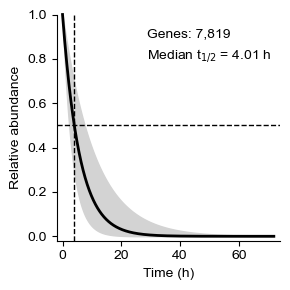

TTseq.K562
0.5 0.8852181975632064 2.104602607369291


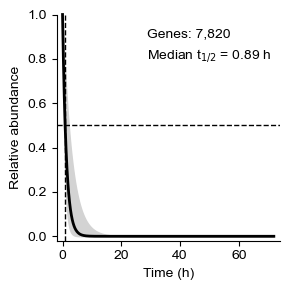

GSE128273_NASCseq.K562
7.896190092470202 14.573584522641148 25.237490899019864


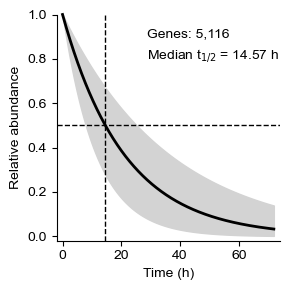

NASCseq.K562
6.077184575008888 11.75109085830361 20.179852852443037


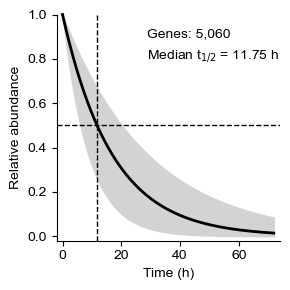

NanoNASCseq.K562.1TC
3.883045245719823 7.527298189295255 13.489668316805773


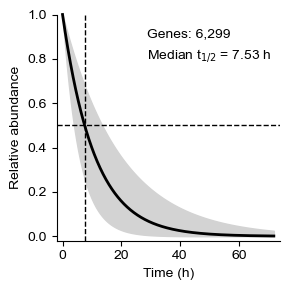

NanoNASCseq.K562.2TC
4.070746346570172 8.85473157289935 18.249638494790126


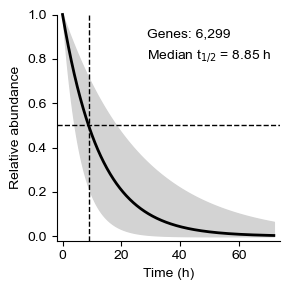

NanoNASCseq.mESC.1TC
0.8107144632819591 1.6455287185950915 3.127091191736335


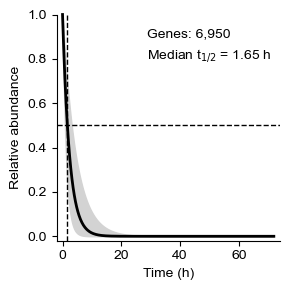

NanoNASCseq.mESC.2TC
0.9030899869919436 1.8249771595963769 3.5680244842860773


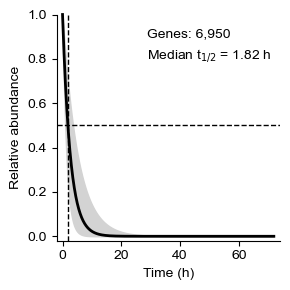

scNTseq.pulse_chase.mESC.Pluripotent
2.25 2.67 3.27


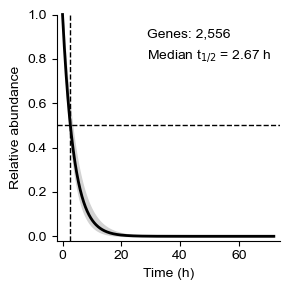

scNTseq.pulse_chase.mESC.Intermediate
1.62 2.6 3.79


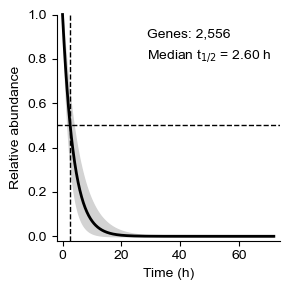

scNTseq.pulse_chase.mESC.2C
1.25 2.94 4.97


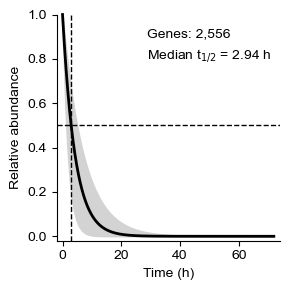

SLAMseq.mESC
2.67063307616926 3.73683442282187 5.16002763920698


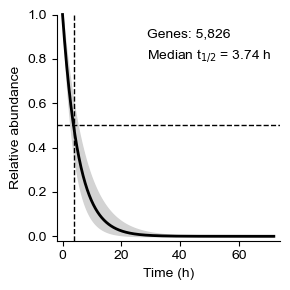

scNTseq.K562
2.7634634650371366 3.9415906920251973 7.464055688451241


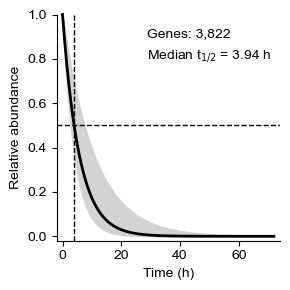

In [43]:
# Distribution of half-life

def adjust_halflife(hts, min_ht=0.5, max_ht=32):
    return [max(min_ht, min(t, max_ht)) for t in hts]
    
def plot_halflife_distribution1(hts, outfile=None, xlim=72):
    hts = adjust_halflife(hts)
    xs = np.arange(0, xlim, 0.1)
    rows = []
    ht = np.median(hts)
    for T in hts:
        ys = [0.5**(x/T) for x in xs]
        rows.append(ys)
    d = pd.DataFrame(rows)
    ys = []
    ys1 = []
    ys2 = []
    for i in d.columns:
        vs = list(sorted(d[i]))
        y = np.median(vs)
        y1 = vs[int(len(vs) * 0.25)]
        y2 = vs[int(len(vs) * 0.75)]
        ys.append(y)
        ys1.append(y1)
        ys2.append(y2)
    plt.figure(figsize=(3, 3))
    plt.plot(xs, ys, color="black", lw=2, clip_on=False)
    plt.fill_between(xs, ys1, ys2, color="lightgrey", clip_on=False)
    plt.text(xlim * 0.4, 0.9, "Genes: %s" % format(len(d), ","))
    plt.text(xlim * 0.4, 0.8, "Median t$_{1/2}$ = %.2f h" % ht)
    plt.axhline(0.5, ls="--", lw=1, color="black")
    plt.axvline(ht, ls="--", lw=1, color="black")
    plt.xlim(0 - 2, xlim + 2)
    plt.ylim(-0.02, 1)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.xlabel("Time (h)")
    plt.ylabel("Relative abundance")
    plt.tight_layout()
    if outfile is None:
        plt.show()
    else:
        plt.savefig(outfile)
        plt.show()

def plot_halflife_distribution(hts, outfile=None, xlim=72, min_ht=0.5, max_ht=32, figsize=(3, 3)):
    hts = list(sorted([max(min_ht, min(t, max_ht)) for t in hts]))
    xs = np.arange(0, xlim, 0.1)
    t1, t2, t3 = hts[int(len(hts)*0.25)], hts[int(len(hts)*0.50)], hts[int(len(hts)*0.75)]
    print(t1, t2, t3)
    ys1, ys2, ys3 = 0.5**(xs/t1), 0.5**(xs/t2), 0.5**(xs/t3)
    plt.figure(figsize=figsize)
    plt.plot(xs, ys2, color="black", lw=2, clip_on=False)
    plt.fill_between(xs, ys1, ys3, color="lightgrey", clip_on=False)
    plt.text(xlim * 0.4, 0.9, "Genes: %s" % format(len(hts), ","))
    plt.text(xlim * 0.4, 0.8, "Median t$_{1/2}$ = %.2f h" % t2)
    plt.axhline(0.5, ls="--", lw=1, color="black")
    plt.axvline(t2, ls="--", lw=1, color="black")
    plt.xlim(0 - 2, xlim + 2)
    plt.ylim(-0.02, 1)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.xlabel("Time (h)")
    plt.ylabel("Relative abundance")
    plt.tight_layout()
    if outfile is None:
        plt.show()
    else:
        plt.savefig(outfile)
        plt.show()        
        
for name, d in data.items():
    print(name)
    outfile = "figures/global_gene_halflife.%s.pdf" % name
    plot_halflife_distribution(d["Halflife"], outfile=outfile)

5060 6299
4522 4522
6.304629902588646 11.91834213609171 20.179852852443037


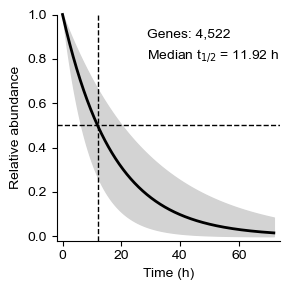

5.479574203736297 11.144684149518786 20.777075169678568


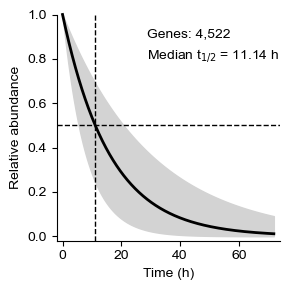

In [22]:
# 半衰期中位数不是转录组所有基因的半衰期中位数，是被检测到的基因的半衰期中位数。

d1 = data["NASCseq.K562"]
d2 = data["NanoNASCseq.K562.2TC"]
print(len(d1), len(d2))
d1 = d1[d1.index.isin(d2.index)]
d2 = d2[d2.index.isin(d1.index)]
print(len(d1), len(d2))

outfile = "figures/global_gene_halflife.%s.pdf" % "NASCseq.K562.final"
plot_halflife_distribution(d1["Halflife"], outfile=outfile)
outfile = "figures/global_gene_halflife.%s.pdf" % "NanoNASCseq.K562.final"
plot_halflife_distribution(d2["Halflife"], outfile=outfile)

## 3. Correlation of half-life (all)

In [14]:
def plot_correlation(names, labels, vmin, vmax, outfile):

    nrow = len(names)
    width, height = nrow * 1.5 + 0.7, nrow * 1.5 + 0.7
    fig, axs = plt.subplots(nrow, nrow, figsize=(width, height), sharex=False, sharey=False,
                            gridspec_kw=dict(wspace=0, hspace=0, left=0.5/width, right=1-0.2/width, bottom=0.5/height, top=1-0.2/height))
    for i in range(len(names)):
        for j in range(len(names)):
            ax = axs[i][j]
            plt.sca(ax)
            if j == 0:
                plt.ylabel(labels[i])
            if i == len(names) - 1:
                plt.xlabel(labels[j])
            if i != j:
                d1, d2 = data[names[j]], data[names[i]]
                s1, s2 = d1["Halflife"], d2["Halflife"]
                d3 = pd.concat([s1, s2], axis=1, join="inner")
                d3.columns = ["T.ref", "T.query"]
                # min_ht = 2**vmin
                # max_ht = 2**vmax
                d3 = d3[(d3.min(axis=1) > 2**vmin) & (d3.max(axis=1) < 2**vmax)]
                xs, ys = d3["T.ref"], d3["T.query"]
                # xs, ys = adjust_halflife(d3["T.ref"]), adjust_halflife(d3["T.query"])
                xs, ys = np.log2(xs), np.log2(ys)
                # print("-" * 40)
                # print("x-axis:", names[j])
                # print("y-axis:", names[i])
                # print("Spearman:", spearmanr(xs, ys))
                r_s, p_s = spearmanr(xs, ys)
                r_p, p_p = pearsonr(xs, ys)
                if i > j:
                    plt.scatter(xs, ys, marker=".", color=plt.colormaps["RdYlBu_r"](0), zorder=1)
                    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
                    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
                elif i < j:
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.9, "r$_s$ = %.2f" % r_s)
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "p$_s$ = %.1e" % p_s)
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.7, "n = %s" % format(len(d3), ","))
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "r$_p$ = %.2f" % r_p)
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.5, "p$_p$ = %.1e" % p_p)
            plt.xlim(vmin, vmax)
            plt.ylim(vmin, vmax)
            if False: # i == len(names) - 1 and j == 0:
                vs1 = np.arange(vmin, vmax + 1)
                vs2 = ["%s" % 2**int(v) for v in vs1]
                plt.xticks(vs1, vs2, rotation=45)
                plt.yticks(vs1, vs2)
            else:
                plt.xticks([])
                plt.yticks([])
    plt.savefig(outfile)
    plt.show()
    plt.close()

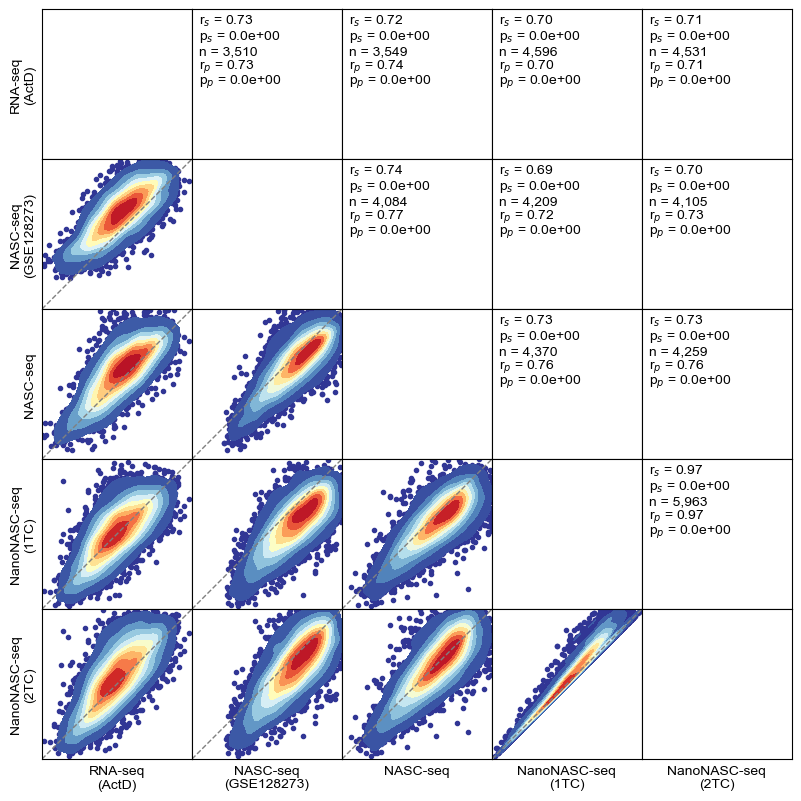

In [16]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.1TC", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq\n(ActD)", "NASC-seq\n(GSE128273)", "NASC-seq", "NanoNASC-seq\n(1TC)", "NanoNASC-seq\n(2TC)"]
vmin, vmax = -1, 6
outfile = "figures/halflife_correlation.K562.pdf"
plot_correlation(names, labels, vmin, vmax, outfile)

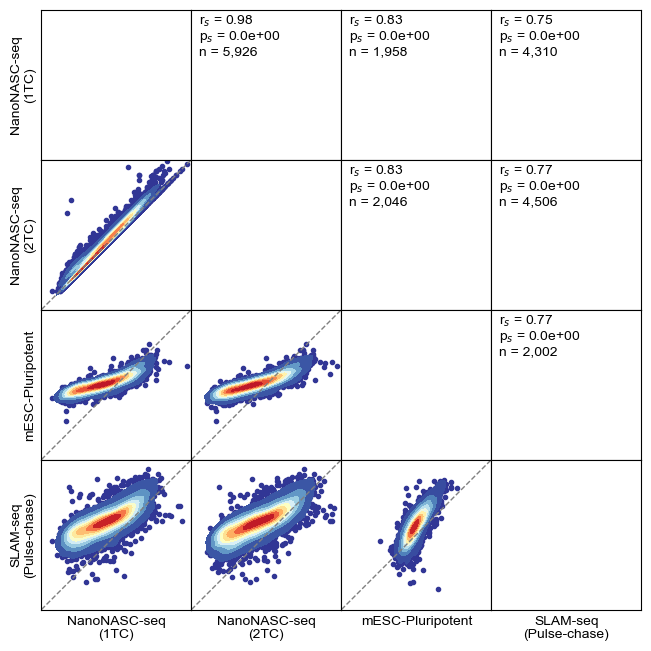

In [27]:
names = ["NanoNASCseq.mESC.1TC", "NanoNASCseq.mESC.2TC", "scNTseq.pulse_chase.mESC.Pluripotent", "SLAMseq.mESC"]
labels = ["NanoNASC-seq\n(1TC)", "NanoNASC-seq\n(2TC)", "mESC-Pluripotent", "SLAM-seq\n(Pulse-chase)"]
vmin, vmax = -2, 5
outfile = "figures/halflife_correlation.mESC.pdf"
plot_correlation(names, labels, vmin, vmax, outfile)

In [13]:
def plot_correlation_of_synthesis_rate(names, labels, outfile=None):
    vmin, vmax = 0, 5
    nrow = len(names)
    width, height = nrow * 1.5 + 0.7, nrow * 1.5 + 0.7
    fig, axs = plt.subplots(nrow, nrow, figsize=(width, height), sharex=False, sharey=False,
                            gridspec_kw=dict(wspace=0, hspace=0, left=0.5/width, right=1-0.2/width, bottom=0.5/height, top=1-0.2/height))
    for i in range(len(names)):
        for j in range(len(names)):
            ax = axs[i][j]
            plt.sca(ax)
            if j == 0:
                plt.ylabel(labels[i])
            if i == len(names) - 1:
                plt.xlabel(labels[j])
            if i != j:
                d1, d2 = data[names[j]], data[names[i]]
                s1, s2 = np.log(1 + d1["SynthesisRate"]*100), np.log(1 + d2["SynthesisRate"]*100)
                d3 = pd.concat([s1, s2], axis=1, join="inner")
                d3.columns = ["SynthesisRate.ref", "SynthesisRate.query"]
                xs, ys = d3["SynthesisRate.ref"], d3["SynthesisRate.query"]
                flags = np.isfinite(xs) & np.isfinite(ys)
                xs, ys = xs[flags], ys[flags]
                r_s, p_s = spearmanr(xs, ys)
                r_p, p_p = pearsonr(xs, ys)
                if i > j:
                    plt.scatter(xs, ys, marker=".", color=plt.colormaps["RdYlBu_r"](0), zorder=1)
                    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
                    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
                elif i < j:
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.9, "n = %s" % format(len(d3), ","))
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "Pearson $\it{r}$ = %.2f" % r_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.7, "p$_p$ = %.1e" % p_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "r$_s$ = %.2f" % r_s)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.5, "p$_s$ = %.1e" % p_s)
            plt.xlim(vmin, vmax)
            plt.ylim(vmin, vmax)
            if False: # i == len(names) - 1 and j == 0:
                vs1 = np.arange(vmin, vmax + 1)
                vs2 = ["%s" % 2**int(v) for v in vs1]
                plt.xticks(vs1, vs2, rotation=45)
                plt.yticks(vs1, vs2)
            else:
                plt.xticks([])
                plt.yticks([])
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

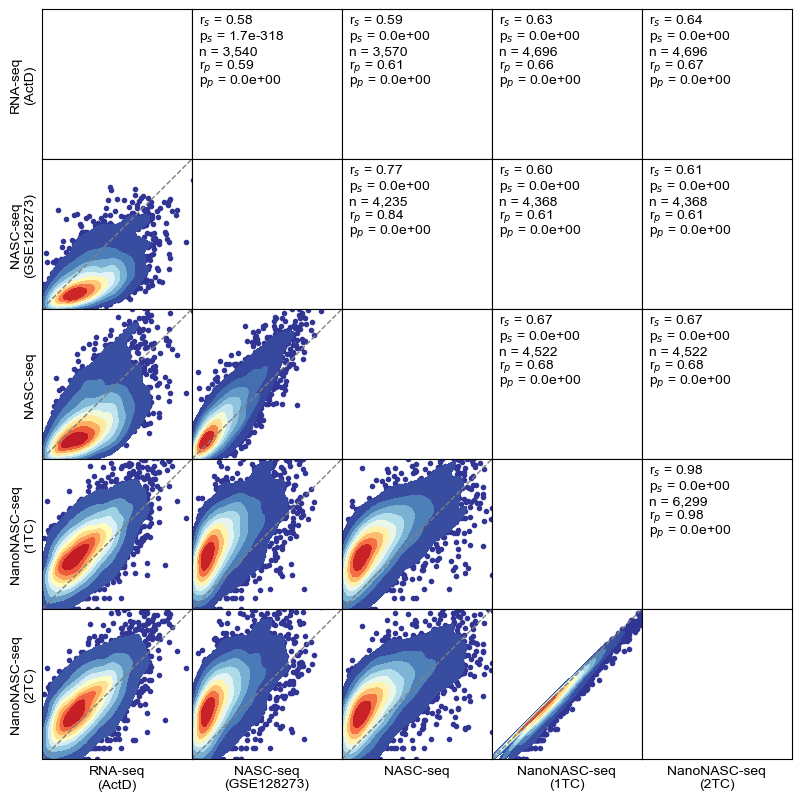

In [15]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.1TC", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq\n(ActD)", "NASC-seq\n(GSE128273)", "NASC-seq", "NanoNASC-seq\n(1TC)", "NanoNASC-seq\n(2TC)"]
plot_correlation_of_synthesis_rate(names, labels, "figures/synthesis_rate_correlation.K562.pdf")

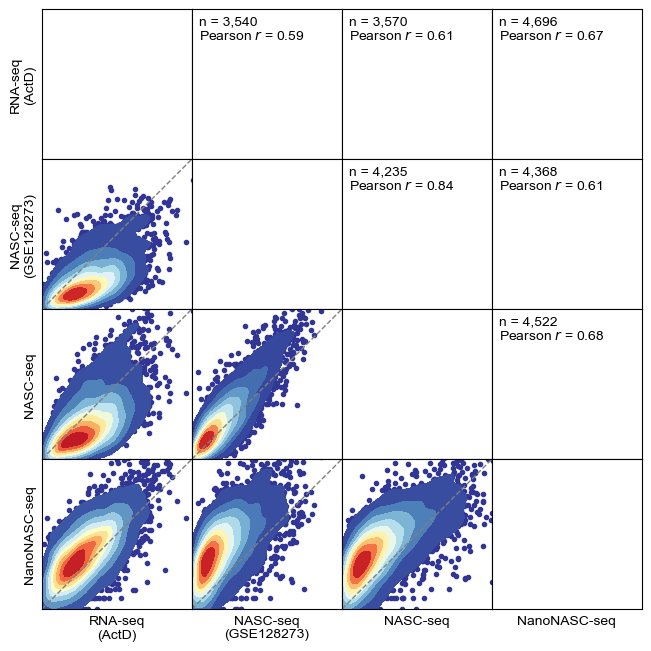

In [25]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq\n(ActD)", "NASC-seq\n(GSE128273)", "NASC-seq", "NanoNASC-seq"]
plot_correlation_of_synthesis_rate(names, labels, "figures/synthesis_rate_correlation.K562.pdf")

In [19]:
def plot_correlation_of_decay_rate(names, labels, outfile=None):
    vmin, vmax = 0, 1.5
    nrow = len(names)
    width, height = nrow * 1.5 + 0.7, nrow * 1.5 + 0.7
    fig, axs = plt.subplots(nrow, nrow, figsize=(width, height), sharex=False, sharey=False,
                            gridspec_kw=dict(wspace=0, hspace=0, left=0.5/width, right=1-0.2/width, bottom=0.5/height, top=1-0.2/height))
    for i in range(len(names)):
        for j in range(len(names)):
            ax = axs[i][j]
            plt.sca(ax)
            if j == 0:
                plt.ylabel(labels[i])
            if i == len(names) - 1:
                plt.xlabel(labels[j])
            if i != j:
                d1, d2 = data[names[j]], data[names[i]]
                s1, s2 = np.log(2)/d1["Halflife"], np.log(2)/d2["Halflife"]
                d3 = pd.concat([s1, s2], axis=1, join="inner")
                d3.columns = ["DecayRate.ref", "DecayRate.query"]
                xs, ys = d3["DecayRate.ref"], d3["DecayRate.query"]
                flags = np.isfinite(xs) & np.isfinite(ys)
                xs, ys = xs[flags], ys[flags]
                r_s, p_s = spearmanr(xs, ys)
                r_p, p_p = pearsonr(xs, ys)
                if i > j:
                    plt.scatter(xs, ys, marker=".", color=plt.colormaps["RdYlBu_r"](0), zorder=1)
                    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
                    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
                elif i < j:
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.9, "n = %s" % format(len(d3), ","))
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "Pearson $\it{r}$ = %.2f" % r_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.7, "p$_p$ = %.1e" % p_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "r$_s$ = %.2f" % r_s)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.5, "p$_s$ = %.1e" % p_s)
            plt.xlim(vmin, vmax)
            plt.ylim(vmin, vmax)
            if False: # i == len(names) - 1 and j == 0:
                vs1 = np.arange(vmin, vmax + 1)
                vs2 = ["%s" % 2**int(v) for v in vs1]
                plt.xticks(vs1, vs2, rotation=45)
                plt.yticks(vs1, vs2)
            else:
                plt.xticks([])
                plt.yticks([])
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

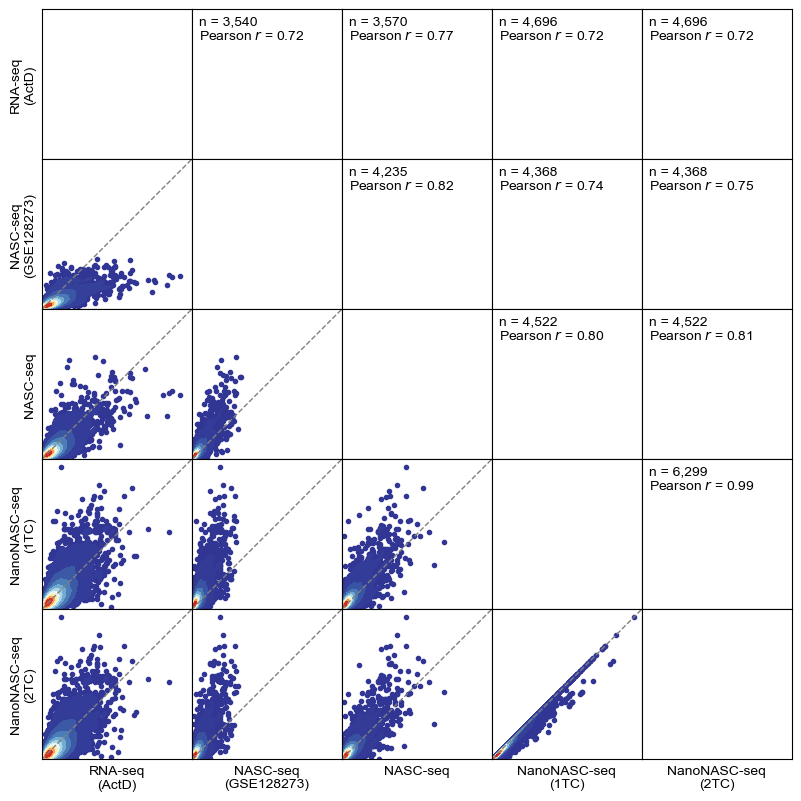

In [20]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.1TC", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq\n(ActD)", "NASC-seq\n(GSE128273)", "NASC-seq", "NanoNASC-seq\n(1TC)", "NanoNASC-seq\n(2TC)"]
plot_correlation_of_decay_rate(names, labels, "figures/decay_rate_correlation.K562.pdf")

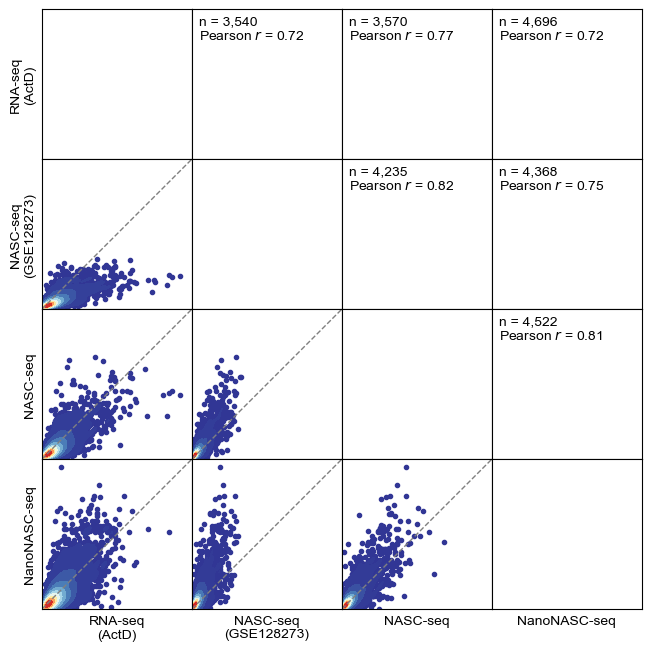

In [21]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq\n(ActD)", "NASC-seq\n(GSE128273)", "NASC-seq", "NanoNASC-seq"]
plot_correlation_of_decay_rate(names, labels, "figures/decay_rate_correlation.K562.pdf")

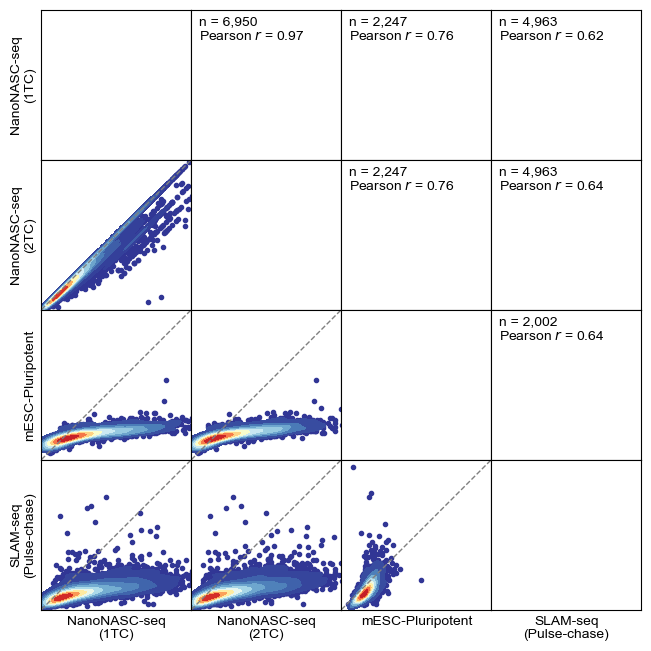

In [22]:
names = ["NanoNASCseq.mESC.1TC", "NanoNASCseq.mESC.2TC", "scNTseq.pulse_chase.mESC.Pluripotent", "SLAMseq.mESC"]
labels = ["NanoNASC-seq\n(1TC)", "NanoNASC-seq\n(2TC)", "mESC-Pluripotent", "SLAM-seq\n(Pulse-chase)"]
plot_correlation_of_decay_rate(names, labels)

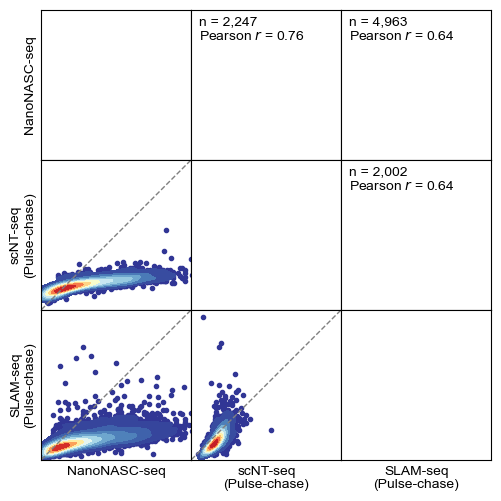

In [23]:
names = ["NanoNASCseq.mESC.2TC", "scNTseq.pulse_chase.mESC.Pluripotent", "SLAMseq.mESC"]
labels = ["NanoNASC-seq", "scNT-seq\n(Pulse-chase)", "SLAM-seq\n(Pulse-chase)"]
plot_correlation_of_decay_rate(names, labels, "figures/decay_rate_correlation.mESC.pdf")

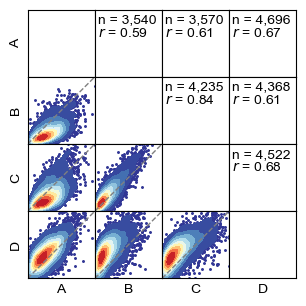

In [27]:
def plot_correlation_of_synthesis_rate(names, labels, outfile=None):
    vmin, vmax = 0, 5
    nrow = len(names)
    width, height = nrow * 1.5 + 0.7, nrow * 1.5 + 0.7
    fig, axs = plt.subplots(nrow, nrow, figsize=(3, 3), sharex=False, sharey=False,
                            gridspec_kw=dict(wspace=0, hspace=0, left=0.5/width, right=1-0.2/width, bottom=0.5/height, top=1-0.2/height))
    for i in range(len(names)):
        for j in range(len(names)):
            ax = axs[i][j]
            plt.sca(ax)
            if j == 0:
                plt.ylabel(labels[i])
            if i == len(names) - 1:
                plt.xlabel(labels[j])
            if i != j:
                d1, d2 = data[names[j]], data[names[i]]
                s1, s2 = np.log(1 + d1["SynthesisRate"]*100), np.log(1 + d2["SynthesisRate"]*100)
                d3 = pd.concat([s1, s2], axis=1, join="inner")
                d3.columns = ["SynthesisRate.ref", "SynthesisRate.query"]
                xs, ys = d3["SynthesisRate.ref"], d3["SynthesisRate.query"]
                flags = np.isfinite(xs) & np.isfinite(ys)
                xs, ys = xs[flags], ys[flags]
                r_s, p_s = spearmanr(xs, ys)
                r_p, p_p = pearsonr(xs, ys)
                if i > j:
                    plt.scatter(xs, ys, marker=".", s=5, color=plt.colormaps["RdYlBu_r"](0), zorder=1)
                    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
                    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
                elif i < j:
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "n = %s" % format(len(d3), ","))
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "$\it{r}$ = %.2f" % r_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.7, "p$_p$ = %.1e" % p_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "r$_s$ = %.2f" % r_s)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.5, "p$_s$ = %.1e" % p_s)
            plt.xlim(vmin, vmax)
            plt.ylim(vmin, vmax)
            if False: # i == len(names) - 1 and j == 0:
                vs1 = np.arange(vmin, vmax + 1)
                vs2 = ["%s" % 2**int(v) for v in vs1]
                plt.xticks(vs1, vs2, rotation=45)
                plt.yticks(vs1, vs2)
            else:
                plt.xticks([])
                plt.yticks([])
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.2TC"]
labels = ["A", "B", "C", "D"]
plot_correlation_of_synthesis_rate(names, labels, "figures/synthesis_rate_correlation.K562.v2.pdf")

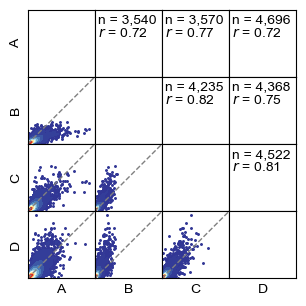

In [25]:
def plot_correlation_of_decay_rate(names, labels, outfile=None):
    vmin, vmax = 0, 1.5
    nrow = len(names)
    width, height = nrow * 1.5 + 0.7, nrow * 1.5 + 0.7
    fig, axs = plt.subplots(nrow, nrow, figsize=(3, 3), sharex=False, sharey=False,
                            gridspec_kw=dict(wspace=0, hspace=0, left=0.5/width, right=1-0.2/width, bottom=0.5/height, top=1-0.2/height))
    for i in range(len(names)):
        for j in range(len(names)):
            ax = axs[i][j]
            plt.sca(ax)
            if j == 0:
                plt.ylabel(labels[i])
            if i == len(names) - 1:
                plt.xlabel(labels[j])
            if i != j:
                d1, d2 = data[names[j]], data[names[i]]
                s1, s2 = np.log(2)/d1["Halflife"], np.log(2)/d2["Halflife"]
                d3 = pd.concat([s1, s2], axis=1, join="inner")
                d3.columns = ["DecayRate.ref", "DecayRate.query"]
                xs, ys = d3["DecayRate.ref"], d3["DecayRate.query"]
                flags = np.isfinite(xs) & np.isfinite(ys)
                xs, ys = xs[flags], ys[flags]
                r_s, p_s = spearmanr(xs, ys)
                r_p, p_p = pearsonr(xs, ys)
                if i > j:
                    plt.scatter(xs, ys, marker=".", s=5, color=plt.colormaps["RdYlBu_r"](0), zorder=1)
                    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
                    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
                elif i < j:
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "n = %s" % format(len(d3), ","))
                    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "$\it{r}$ = %.2f" % r_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.7, "p$_p$ = %.1e" % p_p)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.6, "r$_s$ = %.2f" % r_s)
                    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.5, "p$_s$ = %.1e" % p_s)
            plt.xlim(vmin, vmax)
            plt.ylim(vmin, vmax)
            if False: # i == len(names) - 1 and j == 0:
                vs1 = np.arange(vmin, vmax + 1)
                vs2 = ["%s" % 2**int(v) for v in vs1]
                plt.xticks(vs1, vs2, rotation=45)
                plt.yticks(vs1, vs2)
            else:
                plt.xticks([])
                plt.yticks([])
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.2TC"]
labels = ["A", "B", "C", "D"]
plot_correlation_of_decay_rate(names, labels, "figures/decay_rate_correlation.K562.v2.pdf")

## 4. Correlation of half-life (pairwise)

In [30]:
def plot_single_correlation(names, labels, vmin=-1, vmax=6, outfile=None):
    plt.figure(figsize=(3, 3))
    plt.ylabel(labels[1])
    plt.xlabel(labels[0])
    d1, d2 = data[names[0]], data[names[1]]
    s1, s2 = d1["Halflife"], d2["Halflife"]
    d3 = pd.concat([s1, s2], axis=1, join="inner")
    d3.columns = ["T.ref", "T.query"]
    d3 = d3[(d3.min(axis=1) > 2**vmin) & (d3.max(axis=1) < 2**vmax)]
    xs, ys = d3["T.ref"], d3["T.query"]
    xs, ys = np.log2(xs), np.log2(ys)
    r_s, p_s = spearmanr(xs, ys)
    plt.scatter(xs, ys, marker=".", color=plt.colormaps["RdYlBu_r"](0), zorder=1)
    sns.kdeplot(x=list(xs), y=list(ys), fill=True, cmap='RdYlBu_r', cbar=False, alpha=1, zorder=2)
    plt.plot([vmin, vmax], [vmin, vmax], lw=1, ls="--", color="grey")
    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.88, "$\it{r}$ = %.2f" % r_s)
    #plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.8, "p$_s$ = %.1e" % p_s)
    plt.text(vmin + (vmax - vmin) * 0.05, vmin + (vmax - vmin) * 0.95, "n = %s" % format(len(d3), ","))
    plt.xlim(vmin, vmax)
    plt.ylim(vmin, vmax)
    vs1 = np.arange(vmin, vmax + 1)
    vs2 = ["%s" % 2**int(v) for v in vs1]
    plt.xticks(vs1, vs2)
    plt.yticks(vs1, vs2)
    for loc in ["top", "right"]:
        plt.gca().spines[loc].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

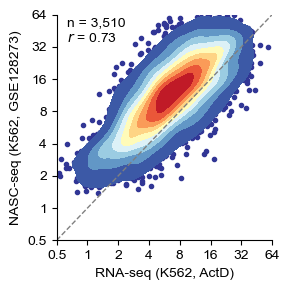

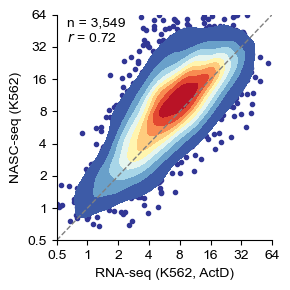

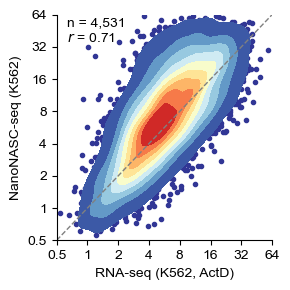

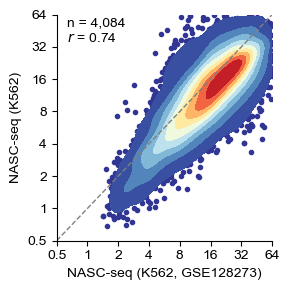

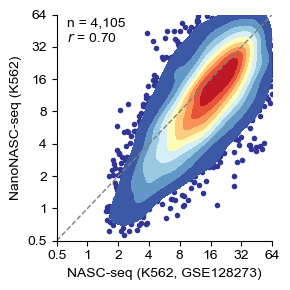

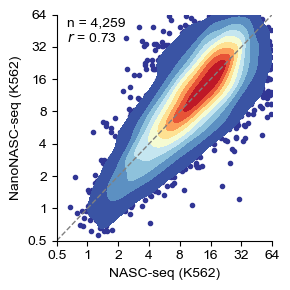

In [34]:
names = ["RNAseq.K562", "GSE128273_NASCseq.K562", "NASCseq.K562", "NanoNASCseq.K562.2TC"]
labels = ["RNA-seq (K562, ActD)", "NASC-seq (K562, GSE128273)", "NASC-seq (K562)", "NanoNASC-seq (K562)"]
vmin, vmax = -1, 6
for i in range(len(names)):
    for j in range(len(names)):
        if i < j:
            names1 = [names[i], names[j]]
            labels1 = [labels[i], labels[j]]
            outfile1 = "figures/halflife_correlation.%s_vs_%s.pdf" % (names1[0], names1[1])
            plot_single_correlation(names1, labels1, vmin, vmax, outfile1)

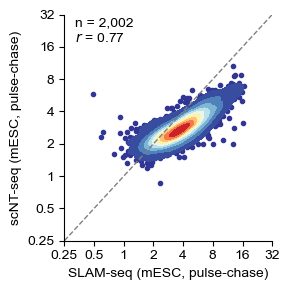

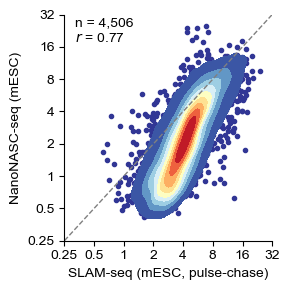

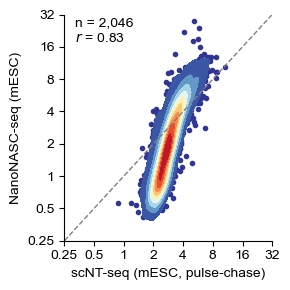

In [33]:
names = ["SLAMseq.mESC", "scNTseq.pulse_chase.mESC.Pluripotent", "NanoNASCseq.mESC.2TC"]
labels = ["SLAM-seq (mESC, pulse-chase)", "scNT-seq (mESC, pulse-chase)", "NanoNASC-seq (mESC)"]
vmin, vmax = -2, 5
for i in range(len(names)):
    for j in range(len(names)):
        if i < j:
            names1 = [names[i], names[j]]
            labels1 = [labels[i], labels[j]]
            outfile1 = "figures/halflife_correlation.%s_vs_%s.pdf" % (names1[0], names1[1])
            plot_single_correlation(names1, labels1, vmin, vmax, outfile1)